## Load packages

In [1]:
library("dartR")
library("ggplot2")
library("dplyr")

Loading required package: adegenet

Loading required package: ade4


   /// adegenet 2.1.11 is loaded ////////////

   > overview: '?adegenet'
   > tutorials/doc/questions: 'adegenetWeb()' 
   > bug reports/feature requests: adegenetIssues()



Loading required package: ggplot2

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: dartR.data

**** Welcome to dartR.data [Version 1.2.2 ] ****


Registered S3 method overwritten by 'pegas':
  method      from
  print.amova ade4

There appears to be a problem with the PROJ installation

Registered S3 method overwritten by 'genetics':
  method      from 
  [.haplotype pegas

**** Welcome to the legacy dartR [Version 2.9.9.5 ] ****


##############################
 Be aware this the legacy version of dartR, which is no longer developed. Pl

In [2]:
#source("outflank.rdata")

##### Outflank and Bayescan results ####
# xx haplotypes
bayescan_idx <- c()
# xx haplotypes
outflank_idx <- c()


## Running outflank

Import the data by using the genepop file

In [4]:
infile <- "../../data/YFT.snp.kinrm.pcrelate.gen"

full_dataset <- import2genind(infile, ncode = 3L)

pop_names <- c("ATL", "GOM", "IVC", "GOM", "SEN", "VZ")

## Change group labels
popNames(full_dataset) <- pop_names



 Converting data from a Genepop .gen file to a genind object... 


File description:  genepop generated from PopData by PopGen.jl. SNP positions manually restored 

...done.



Run OutFLANK using dartR wrapper script


Calculating FSTs, may take a few minutes...
[1] "10000 done of 15748"


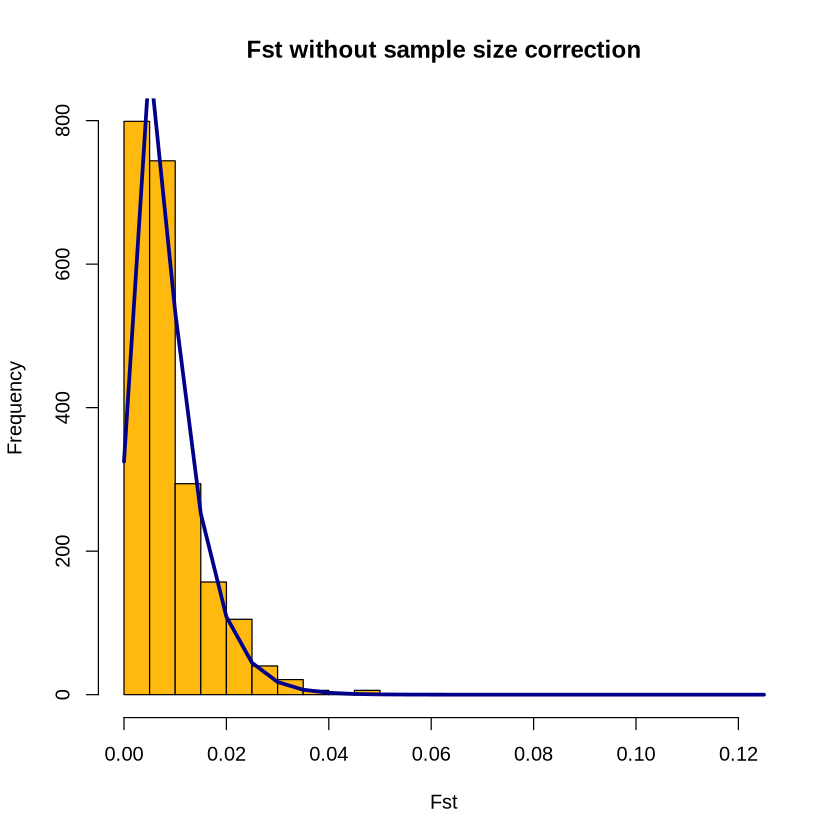

In [5]:
full_outflnk <- gl.outflank(
  full_dataset,
  Hmin = 0.1,
  qthreshold = 0.01,
  LeftTrimFraction = 0.05,
  RightTrimFraction = 0.1
)

## Processing results
## Outliers

In [6]:
full_outflnk <- full_outflnk$outflank$results


Remove duplicated rows for each SNP


In [7]:
toRemove <- seq(1, nrow(full_outflnk), by = 2)
full_outflnk <- full_outflnk[-toRemove, ]


Check for linear conformity, remove loci that deviate substantially. Also a good time to remove NA values and assess whether it's a true outlier when its `He`terozygosity is >= 0.1.


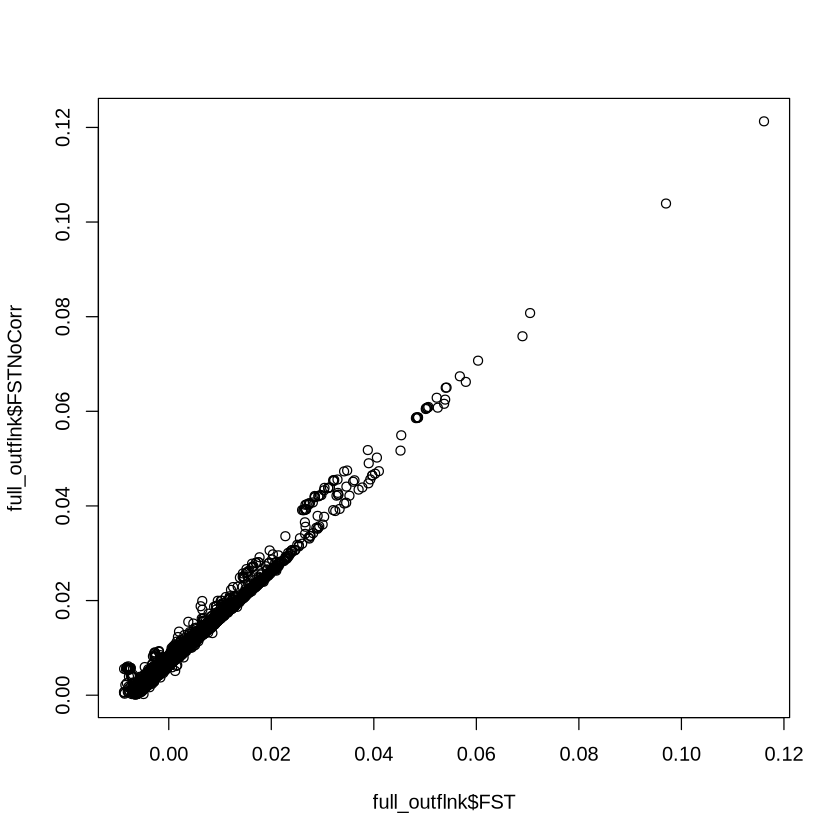

In [8]:
plot(full_outflnk$FST, full_outflnk$FSTNoCorr)

full_outflnk <- full_outflnk[!is.na(full_outflnk$He),] %>%
  mutate(
    putative = case_when(
      (He >= 0.1 & OutlierFlag == TRUE) ~ TRUE,
      (He >= 0.1 & OutlierFlag == FALSE) ~ FALSE,
      (He < 0.1) ~ FALSE
    )
  )


Saving 7 x 7 in image


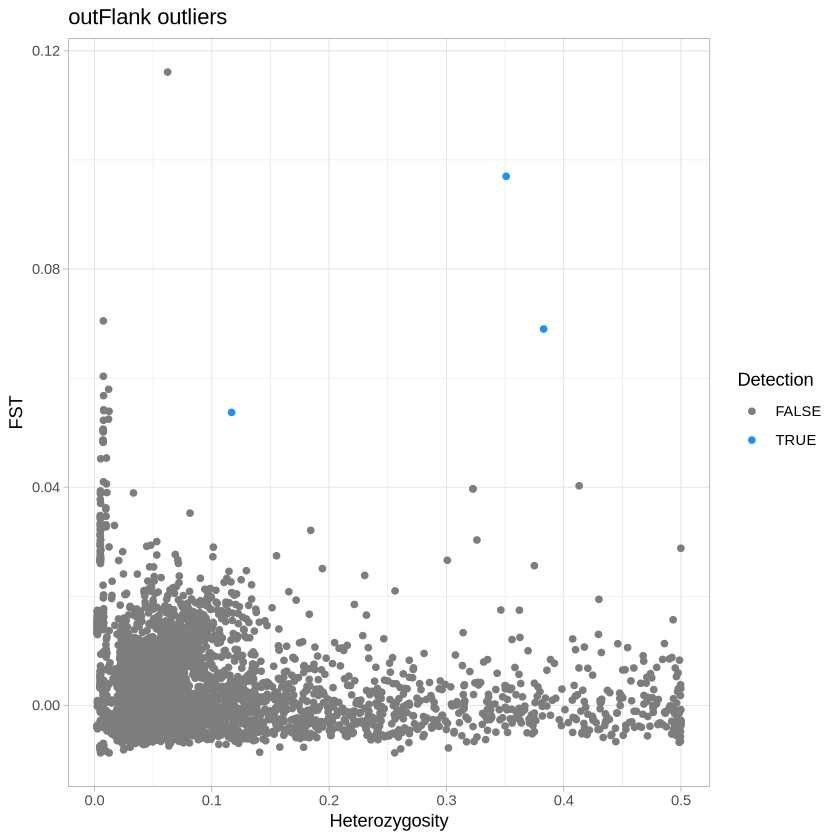

In [9]:
full_outflnk %>% 
ggplot(aes(x = He, y = FST)) + 
  geom_point(aes(color = putative)) +
  scale_color_manual(values = c("grey49", "dodgerblue")) +
  theme_light() +
  labs(title = "outFlank outliers" , x = "Heterozygosity", y = "FST", color = "Detection")

ggsave(filename = "outflank_outliers.snps.png")

pull out outliers w/ He > 0.1


In [16]:
putatives <- full_outflnk |> filter(He >= 0.1 & OutlierFlag == TRUE)
write.csv(
    putatives,
    file = "outFLANK_putatives.csv",
    row.names = FALSE,
    quote = FALSE
)


## Write output files

In [20]:
write.csv(
  full_outflnk,
  file = "outFLANK_FST.csv",
  row.names = FALSE,
  quote = FALSE
)

full_out.outflnk <- locNames(full_dataset)[out_index]
full_out.outflnk

# output only outlier loci
write.table(full_out.outflnk, file="outlier_outFLANK.csv", sep = ",", row.names = FALSE, quote = FALSE, col.names = FALSE)


[1] "Talbacares_contig_3421_383094" "Talbacares_lg_1_13713629"     
[3] "Talbacares_lg_5_18593677"

## Figures
### qvalue hist


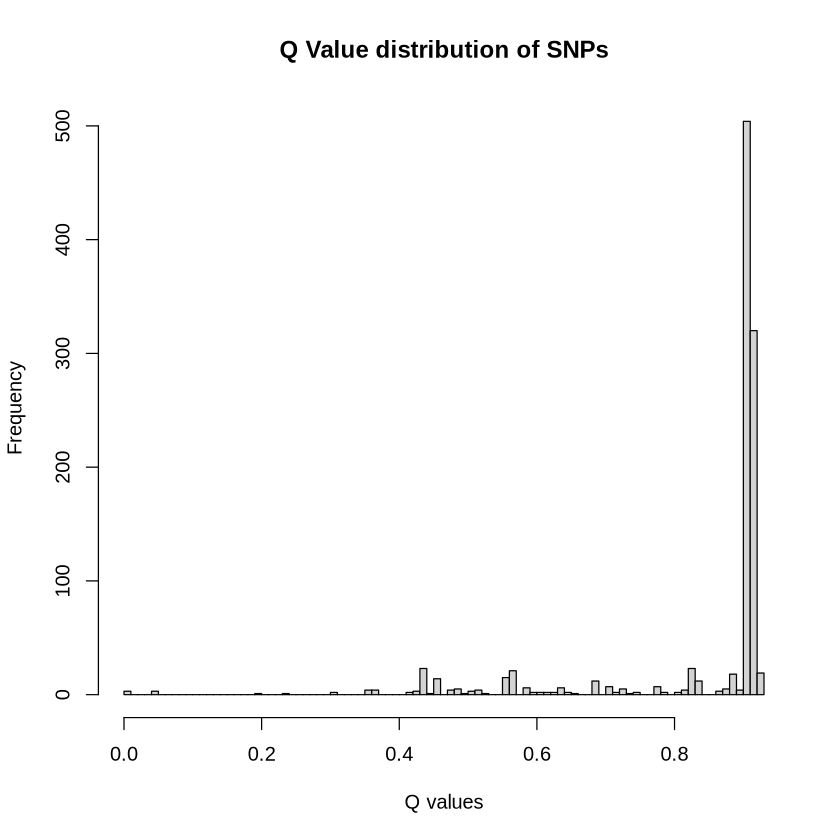

In [18]:
hist(
  full_outflnk$qvalues,
  breaks = 100,
  xlab = "Q values",
  main = "Q Value distribution of SNPs"
)

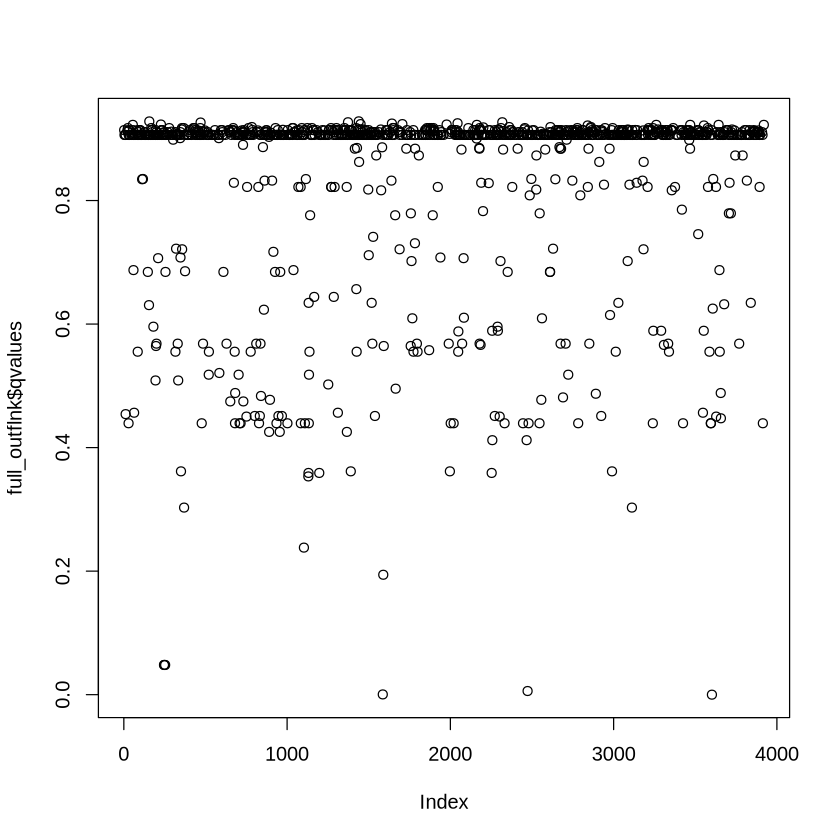

In [19]:
plot(x = full_outflnk$qvalues)